In [179]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [180]:
output_paths = list(Path('saddler_eval').glob('**/*.pkl'))
# output_paths

In [181]:
# path.stem.split(path.parent.name)[-1].split('_')[-3]

In [182]:
results_dfs = []
for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    # reformat dict
    record = {}
    record['accuracy'] = res_dict['acc']
    record['std_error'] = res_dict['std_err']
    record['model'] = path.parent.name
    #parts of name 
    parts = path.stem.split(path.parent.name)[-1].split('_')        
    record['condition'] = parts[1]
    if 'clean' in path.stem:
        record['snr'] = np.inf
    else:
        record['snr'] = int(parts[-3])

    df = pd.DataFrame.from_records([record])
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [183]:
results

,accuracy,std_error,model,condition,snr
0,0.367021,0.024890,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-12.0
0,0.742021,0.022594,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-3.0
0,0.643617,0.024732,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-6.0
0,0.478723,0.025797,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-9.0
0,0.771277,0.021689,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,0.0
0,0.789894,0.021037,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,3.0
0,0.063830,0.012623,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,babble,-12.0
0,0.523936,0.025790,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,babble,-3.0
0,0.316489,0.024018,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,babble,-6.0
0,0.148936,0.018385,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,babble,-9.0


In [184]:
human_df = pd.read_csv('/mindhive/mcdermott/www/msaddler/msjspsych/experiment_word_recognition/data/human_experiment_v00/combined_results.csv')

In [185]:
## group by 

In [186]:
# fg_manifest['word'].map(word_2_class)

test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "ieee": "background_ieeeaaspcasa",
                       "clean": "background_SILENCE"}

path_to_cond = {v:k for k,v in test_condition_dict.items()}

In [187]:
human_df.head()

,background_condition,correct/count,correct/mean,correct/sum,participant_age,participant_gender,participant_hearing_loss,participant_id,snr
0,background_SILENCE,15,0.866667,13.0,32,Male,False,544e94c4fdf99b50bd30726c,inf
1,background_cv08talkerbabble,14,0.000000,0.0,32,Male,False,544e94c4fdf99b50bd30726c,-9.0
2,background_cv08talkerbabble,14,0.000000,0.0,32,Male,False,544e94c4fdf99b50bd30726c,-6.0
3,background_cv08talkerbabble,14,0.214286,3.0,32,Male,False,544e94c4fdf99b50bd30726c,-3.0
4,background_cv08talkerbabble,14,0.500000,7.0,32,Male,False,544e94c4fdf99b50bd30726c,0.0


In [188]:
## group human_df by participant_id, background_background, and snr, and compute mean accuracy and std error for correct/mean column

human_results = human_df.groupby(['background_condition', 'snr']).agg({'correct/mean': ['mean', 'sem']}).reset_index()

human_results.columns = ['background_condition', 'snr', 'accuracy', 'std_error']

human_results['model'] = 'human'

human_results['condition'] = human_results['background_condition'].map(path_to_cond)

In [189]:
human_results

,background_condition,snr,accuracy,std_error,model,condition
0,background_SILENCE,inf,0.788693,0.016813,human,clean
1,background_cv08talkerbabble,-9.0,0.023403,0.004757,human,babble
2,background_cv08talkerbabble,-6.0,0.054161,0.007746,human,babble
3,background_cv08talkerbabble,-3.0,0.168683,0.012997,human,babble
4,background_cv08talkerbabble,0.0,0.376188,0.015179,human,babble
5,background_cv08talkerbabble,3.0,0.561132,0.018973,human,babble
6,background_ieeeaaspcasa,-9.0,0.155742,0.011367,human,ieee
7,background_ieeeaaspcasa,-6.0,0.260333,0.015056,human,ieee
8,background_ieeeaaspcasa,-3.0,0.418723,0.016392,human,ieee
9,background_ieeeaaspcasa,0.0,0.573885,0.018567,human,ieee


In [190]:
combined = pd.concat([results, human_results], axis=0, ignore_index=True)

In [191]:
combined

,accuracy,std_error,model,condition,snr,background_condition
0,0.367021,0.024890,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-12.0,NaN
1,0.742021,0.022594,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-3.0,NaN
2,0.643617,0.024732,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-6.0,NaN
3,0.478723,0.025797,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,-9.0,NaN
4,0.771277,0.021689,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,audioset,0.0,NaN
...,...,...,...,...,...,...
58,0.333188,0.016636,human,music,-9.0,background_musdb18hq
59,0.423887,0.018321,human,music,-6.0,background_musdb18hq
60,0.564174,0.020741,human,music,-3.0,background_musdb18hq
61,0.648603,0.019850,human,music,0.0,background_musdb18hq


In [192]:
# replace inf in snr with 6 
combined['snr'] = combined['snr'].replace(np.inf, 6)

# replace ieee with natural scene
combined['condition'] = combined['condition'].replace('ieee', 'natural scene')
combined.model.unique()



array(['attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor',
       'human'], dtype=object)

Text(0.5, 1.0, 'Human')

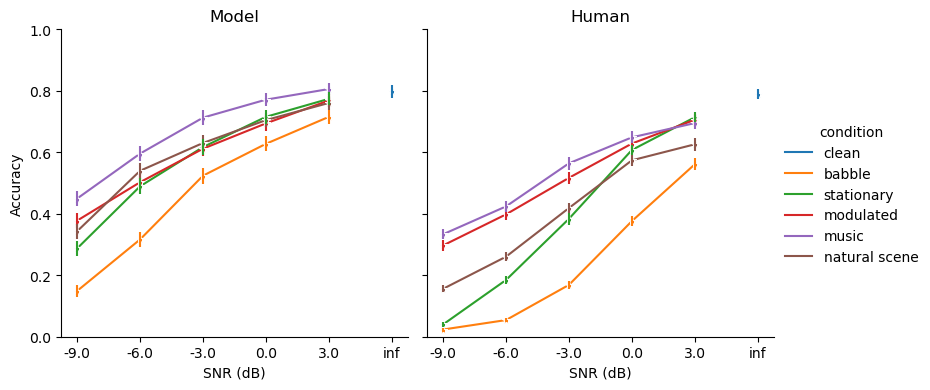

In [193]:
to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', ]

palette = dict(zip(hue_order, sns.color_palette(n_colors=len(hue_order)+2, as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='condition', hue_order=hue_order, col="model",
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['model'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
g.axes.flat[0].set_ylabel('Accuracy')
g.axes.flat[1].set_ylabel('')
g.axes.flat[0].set_xlabel('SNR (dB)')
g.axes.flat[1].set_xlabel('SNR (dB)')
g.axes.flat[0].set_title('Model')
g.axes.flat[1].set_title('Human')


# plt.tight_layout()

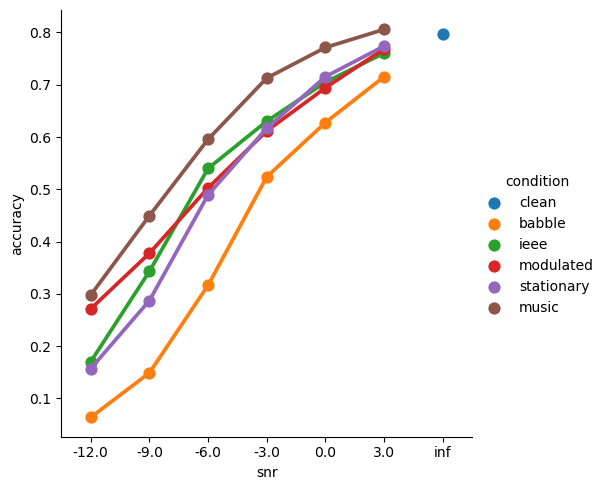

In [51]:
hue_order_model = ['clean', 'babble', 'ieee', 'modulated', 'stationary', 'music']
sns.catplot(data=results[results.condition != 'audioset'], x='snr', y='accuracy', hue='condition', hue_order=hue_order_model, kind='point')